In [2]:
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset, Subset, DataLoader
import torch.optim as optim

from tqdm import tqdm
from vae import VariationalAutoEncoder, kl_loss_function, mse_loss_function, sample

from PIL import Image

import pandas as pd

In [3]:
path = '/home/alzorrcarri/Documentos/diffusion_models/ldp/skin_lession_images'

df_labels = pd.read_csv(path + '/train-metadata.csv', sep = ',', header = 0)
df_labels = df_labels[['isic_id', 'target']]

In [4]:
image_size = 128
device = 'cuda'

In [5]:
images = []
labels = []
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)), 
    transforms.ToTensor()])

for n_row in range(df_labels.shape[0]):
    image_name, image_label = df_labels.loc[n_row]
    image_path = path + '/train-image/image/' + image_name + '.jpg'
    if os.path.isfile(image_path):
        image = Image.open(image_path)
        image = transform(image)
        images.append(image)
        labels.append(int(image_label))

0


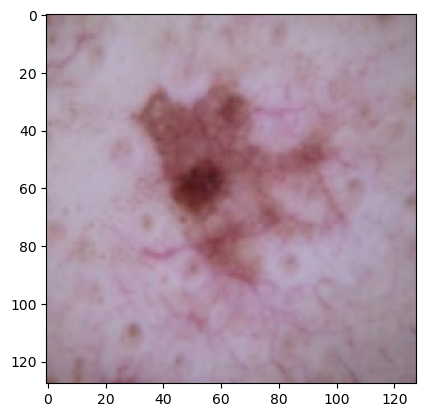

In [6]:
import matplotlib.pyplot as plt

plt.imshow(images[0].permute(1, 2, 0))
print(labels[0])

In [7]:
images[0].shape

torch.Size([3, 128, 128])

In [8]:
len(images), len(labels)

(7496, 7496)

In [9]:
images_tensor = torch.stack(images)
labels_tensor = torch.Tensor(labels)

In [10]:
images_tensor.shape, labels_tensor.shape

(torch.Size([7496, 3, 128, 128]), torch.Size([7496]))

In [11]:
class new_Dataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

# Crear el dataset con las imágenes de melanoma de piel
dataset = new_Dataset(images_tensor, labels_tensor)

In [12]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [13]:
def VAE_train(model, dataloader, optimizer, epochs):
    for epoch in range(epochs):
        mse_loss_sum = 0
        kl_loss_sum = 0
        loss_sum = 0
        
        pbar = tqdm(enumerate(dataloader), total=len(dataloader))
        pbar.set_description(f"Epoch {epoch} - Training")
        for i, batch in pbar:
            x, _ = batch
            x = x.to(device)
            mean, log_var = model.encoder(x)
            z_sample = sample(mean, log_var)
            x_bar = model.decoder(z_sample)

            mse_loss = mse_loss_function(x, x_bar)
            kl_loss = kl_loss_function(mean, log_var)
            loss = torch.mean(mse_loss + kl_loss)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            mse_loss_sum += mse_loss.item()
            kl_loss_sum += kl_loss.item()
            loss_sum += loss.item()
            pbar.set_postfix({'mse_loss' : mse_loss_sum / (i+1), 'kl_loss' : kl_loss_sum / (i+1), 'loss' : loss_sum /(i+1)})

    return model

In [14]:
image_shape = [32, 3, image_size, image_size]
model = VariationalAutoEncoder(latent_dim=30, image_shape=image_shape).to(device)
optimizer = torch.optim.Adam(model.parameters())
model.train()
model = VAE_train(model, dataloader, optimizer, epochs=50)

Epoch 49 - Training: 100%|██████████| 235/235 [00:18<00:00, 12.45it/s, mse_loss=2.55e+3, kl_loss=1.31e+3, loss=3.86e+3]


In [222]:
torch.save(model.state_dict(), 'vae_model.pth')

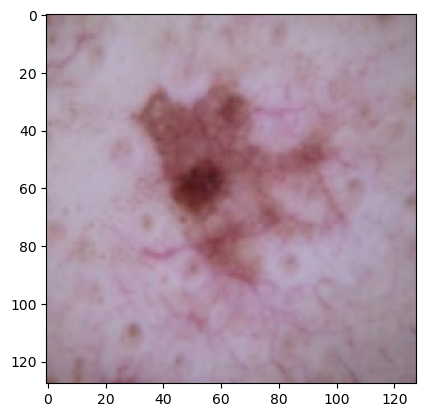

In [15]:
plt.imshow(images_tensor[0].permute(1, 2, 0))

In [16]:
x = images_tensor[0].unsqueeze(0).to(device)
mean, log_var = model.encoder(x)
z_sample = sample(mean, log_var)
x_bar = model.decoder(z_sample)

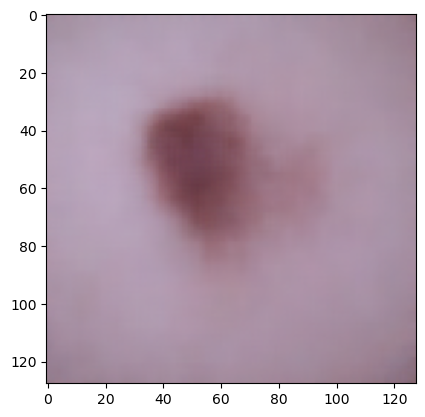

In [17]:
plt.imshow(x_bar[0].permute(1, 2, 0).to('cpu').detach().numpy())

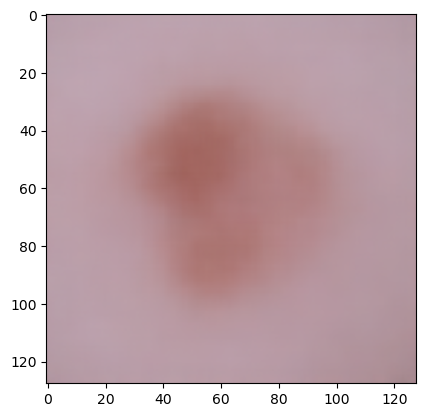

In [25]:
# Interpolación de imágenes
x0 = images_tensor[0].unsqueeze(0).to(device)
x1 = images_tensor[1].unsqueeze(0).to(device)
x = x0 + 0.5 * (x1 - x0)
mean, log_var = model.encoder(x)
z_sample = sample(mean, log_var)
x_bar = model.decoder(z_sample)
plt.imshow(x_bar[0].permute(1, 2, 0).to('cpu').detach().numpy())

In [26]:
latent_images = []
labels = []

model.eval()
with torch.no_grad():
    for image, label in dataloader:
        image = image.to(device)
        mean, log_var = model.encoder(image)
        z = sample(mean, log_var)
        latent_images.append(z)
        labels.append(label)

In [27]:
latent_images = torch.cat(latent_images)
labels = torch.cat(labels)

In [28]:
latent_images.shape, labels.shape

(torch.Size([7496, 30]), torch.Size([7496]))

In [29]:
labels

tensor([0., 0., 1.,  ..., 1., 0., 1.])

In [30]:
latent_images[0][0:2].cpu().detach().numpy().tolist()

[1.2942074537277222, -0.9543797373771667]

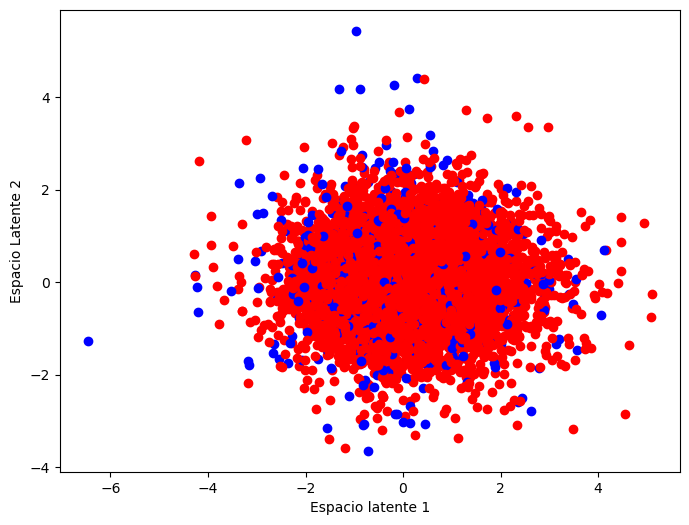

In [31]:
# Crear una figura
plt.figure(figsize=(8, 6))

# Definir una lista de colores para las etiquetas
colors = ['red', 'blue']

# Iterar sobre cada imagen en latent_images
for i in range(latent_images.shape[0]):
    # Obtener las coordenadas (asumimos que son las primeras dos dimensiones)
    coordinates = latent_images[i][0:2].cpu().detach().numpy().tolist()
    
    # Obtener la etiqueta y convertirla a entero
    label = int(labels[i])
    
    # Graficar el punto, eligiendo el color basado en la etiqueta
    plt.scatter(coordinates[0], coordinates[1], color=colors[label])

# Añadir etiquetas a los ejes
plt.xlabel('Espacio latente 1')
plt.ylabel('Espacio Latente 2')

# Mostrar el gráfico
plt.show()


In [32]:
class LatentDataset(Dataset):
    def __init__(self, latents, labels):
        self.latents = latents
        self.labels = labels

    def __len__(self):
        return len(self.latents)

    def __getitem__(self, idx):
        return self.latents[idx], self.labels[idx]

# Crear el dataset con las codificaciones latentes
latent_dataset = LatentDataset(latent_images, labels)

In [36]:
# Filtrar los índices de las muestras que pertenecen a la clase del 1
indices_clase_1 = [i for i, (img, label) in enumerate(latent_dataset) if label == 1.]

# Crear un dataset con solo esos ejemplos (usando Subset)
latent_dataset_clase_1 = Subset(latent_dataset, indices_clase_1)

latent_dataloader = DataLoader(latent_dataset_clase_1, batch_size=32, shuffle=True)

In [34]:
# Filtrar los índices de las muestras que pertenecen a la clase del 1
indices_clase_0 = [i for i, (img, label) in enumerate(latent_dataset) if label == 0.]

# Crear un dataset con solo esos ejemplos (usando Subset)
latent_dataset_clase_0 = Subset(latent_dataset, indices_clase_0)

latent_dataloader = DataLoader(latent_dataset_clase_0, batch_size=32, shuffle=True)

In [35]:
len(latent_dataset_clase_1), len(latent_dataset_clase_0)

(662, 6834)

In [86]:
T = 50  # Número de pasos de difusión
betas = torch.linspace(1e-4, 0.02, T).to(device)  # Coeficiente beta para cada paso de difusión
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas, dim=0)  # Producto acumulado de alphas

In [87]:
def add_noise(x, t):
    sqrt_alpha_hat = torch.sqrt(alpha_hat[t])[:, None]
    sqrt_one_minus_alpha_hat = torch.sqrt(1 - alpha_hat[t])[:, None]
    epsilon = torch.randn_like(x)
    return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * epsilon, epsilon

In [88]:
class DiffusionModel(nn.Module):
    def __init__(self, latent_dim):
        super(DiffusionModel, self).__init__()
        self.fc1 = nn.Linear(latent_dim + 1, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, latent_dim)

    def forward(self, x, t):
        """
        x: Latente con ruido en el paso t.
        t: Paso de tiempo (agregado como característica adicional).
        """
        t_embedded = t.unsqueeze(1).float()  # Asegurar que t tiene una dimensión para concatenar
        x = torch.cat([x, t_embedded], dim=1)  # Concatenar x con el tiempo t
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [89]:
# Definir el modelo de difusión
latent_dim = latent_images.shape[1]  # Dimensión del espacio latente
diffusion_model = DiffusionModel(latent_dim).to(device)
optimizer = optim.Adam(diffusion_model.parameters(), lr=1e-5)

# Bucle de entrenamiento
epochs = 100

for epoch in range(epochs):
    diffusion_model.train()
    running_loss = 0.0

    for latents, _ in latent_dataloader:  # Usamos nuestro DataLoader de codificaciones latentes
        # Selecciona un paso t aleatorio para cada ejemplo en el batch
        t = torch.randint(0, T, (latents.size(0),))
        t = t.to(device)

        latents = latents.to(device)

        # añadimos ruido a las imágenes
        noisy_latents, noise = add_noise(latents, t)

        # Predecir el ruido usando el modelo de difusión
        noise_pred = diffusion_model(noisy_latents, t)

        # Calcular la pérdida como la MSE entre el ruido real y el ruido predicho
        loss = F.mse_loss(noise_pred, noise)

        # Optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss / len(latent_dataloader)}')

Epoch [1/100], Loss: 1.3604587600344704
Epoch [2/100], Loss: 1.191058581783658
Epoch [3/100], Loss: 1.0779792070388794
Epoch [4/100], Loss: 1.0527562073298864
Epoch [5/100], Loss: 1.0177082362629117
Epoch [6/100], Loss: 1.0233389479773385
Epoch [7/100], Loss: 1.0147369844572884
Epoch [8/100], Loss: 1.0061286148570834
Epoch [9/100], Loss: 1.000721616404397
Epoch [10/100], Loss: 0.9980543823469252
Epoch [11/100], Loss: 0.9962486851783026
Epoch [12/100], Loss: 0.9957642328171503
Epoch [13/100], Loss: 0.986856480439504
Epoch [14/100], Loss: 1.020878641378312
Epoch [15/100], Loss: 1.0050826015926542
Epoch [16/100], Loss: 0.9981038996151516
Epoch [17/100], Loss: 1.0107684476034982
Epoch [18/100], Loss: 1.0044559325490678
Epoch [19/100], Loss: 1.0136647451491583
Epoch [20/100], Loss: 0.9830590429760161
Epoch [21/100], Loss: 0.9930717576117742
Epoch [22/100], Loss: 0.9818195672262282
Epoch [23/100], Loss: 1.003255301997775
Epoch [24/100], Loss: 0.978230044955299
Epoch [25/100], Loss: 1.0070722

In [90]:
def sample_latent(diffusion_model, latent_dim, T):
    diffusion_model.eval()
    with torch.no_grad():
        # Comenzar desde ruido puro
        z = torch.randn(1, latent_dim).to(device)
        # Revertir el proceso de difusión paso a paso
        for t in reversed(range(T)):
            t_tensor = torch.full((1,), t, dtype=torch.long).to(device)
            noise_pred = diffusion_model(z, t_tensor)
            z = (z - torch.sqrt(betas[t]) * noise_pred) / torch.sqrt(1 - betas[t])
    return z

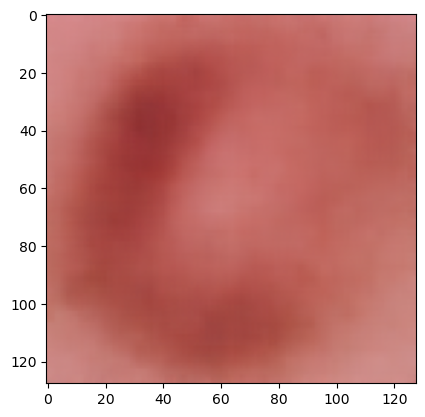

In [101]:
model.eval()

z = sample_latent(diffusion_model, latent_dim, T)

x_bar = model.decoder(z)

plt.imshow(x_bar[0].permute(1, 2, 0).cpu().detach().numpy())